# Compact LJ response and rollout

Physical-coordinate endpoint p-ratio R² by response step. Reconstruction and autonomous rollout are separate post-fit claims. This reader trains nothing and does not select checkpoints.

## Data contract

Preferred input: `notebooks/results/compact_lj_response_rollout/response_seed_results.csv`, one row per `variant, seed, source, frame, kind, strategy`, with these required columns: `variant`, `seed`, `source`, `frame`, `kind` (`reconstruction` or `autonomous`), `strategy` (`ae`, `one_step`, or `multistep8`), `p_ratio_r2`, `valid`, `total`. Additional audit columns are allowed. `valid` and `total` are per-seed counts. The reader also adapts the existing reconstruction collector while the unified file is being populated.

In [1]:
%matplotlib inline
from pathlib import Path
import sys
import importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'src' / 'lss').exists():
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

# Load plotting directly so this reader stays usable in lightweight notebook kernels.
_plotting_spec = importlib.util.spec_from_file_location('lss_plotting', ROOT / 'src' / 'lss' / 'plotting.py')
_plotting = importlib.util.module_from_spec(_plotting_spec)
_plotting_spec.loader.exec_module(_plotting)
apply_editorial_style = _plotting.apply_editorial_style
DATASET_COLORS, PAPER_COLORS = _plotting.DATASET_COLORS, _plotting.PAPER_COLORS
apply_editorial_style()

RESULTS = ROOT / 'notebooks' / 'results'
UNIFIED = RESULTS / 'compact_lj_response_rollout' / 'response_seed_results.csv'
LEGACY = RESULTS / 'compact_lj_pratio' / 'collection' / 'source_frame_seed_results.csv'
SOURCES = ('reid', 'depablo_low_temp', 'lj_noisy', 'depablo_mixed_temp')
SOURCE_LABELS = {
    'reid': 'Reid',
    'depablo_low_temp': 'dePablo low-T',
    'lj_noisy': 'Noisy LJ',
    'depablo_mixed_temp': 'Mixed-T transfer',
}
VARIANT_LABELS = {
    'mp2_r16_d2': 'MP 2D',
    'mp2_r16_d4': 'MP 4D',
}
STRATEGY_LABELS = {'ae': 'AE observed frame', 'one_step': 'Autonomous one-step', 'multistep8': 'Autonomous multistep-8'}
STRATEGY_STYLES = {'ae': '-', 'one_step': '--', 'multistep8': ':'}
STRATEGY_COLORS = {'ae': PAPER_COLORS['blue'], 'one_step': PAPER_COLORS['red'], 'multistep8': PAPER_COLORS['purple']}


In [2]:
REQUIRED = {'variant', 'seed', 'source', 'frame', 'kind', 'strategy', 'p_ratio_r2', 'valid', 'total'}

def read_unified(path):
    table = pd.read_csv(path)
    missing = REQUIRED.difference(table.columns)
    if missing:
        raise ValueError(f'{path} is missing required columns: {sorted(missing)}')
    table = table[list(REQUIRED)].copy()
    bad_kind = set(table['kind'].dropna()) - {'reconstruction', 'autonomous'}
    if bad_kind:
        raise ValueError(f'{path} has unsupported kind values: {sorted(bad_kind)}')
    table['origin'] = 'unified'
    return table

def read_legacy(path):
    table = pd.read_csv(path)
    needed = {'variant', 'seed', 'source', 'frame', 'p_ratio_r2', 'valid', 'total'}
    missing = needed.difference(table.columns)
    if missing:
        raise ValueError(f'{path} cannot be adapted; missing: {sorted(missing)}')
    table = table[table.get('split', 'validation').isin(['validation', 'mixed_transfer'])].copy()
    table['kind'] = 'reconstruction'
    table['strategy'] = 'ae'
    table['origin'] = 'legacy reconstruction collector'
    return table[list(REQUIRED) + ['origin']]

tables, discovered = [], []
if UNIFIED.exists():
    tables.append(read_unified(UNIFIED)); discovered.append(UNIFIED.relative_to(ROOT))
if LEGACY.exists():
    tables.append(read_legacy(LEGACY)); discovered.append(LEGACY.relative_to(ROOT))

if tables:
    response = pd.concat(tables, ignore_index=True)
    response['variant_label'] = response['variant'].map(VARIANT_LABELS).fillna(response['variant'])
    response = response[response['source'].isin(SOURCES)].copy()
    # The unified contract supersedes a legacy row with the same scientific key.
    response['priority'] = response['origin'].eq('unified').astype(int)
    response = (response.sort_values('priority')
                        .drop_duplicates(['variant', 'seed', 'source', 'frame', 'kind'], keep='last'))
    response = response.drop(columns='priority')
    print('Read:', *map(str, discovered), sep='\n  ')
else:
    response = pd.DataFrame(columns=list(REQUIRED) + ['origin', 'variant_label'])
    print('No response CSV is available yet. Expected:', UNIFIED.relative_to(ROOT))


Read:
  notebooks/results/compact_lj_response_rollout/response_seed_results.csv
  notebooks/results/compact_lj_pratio/collection/source_frame_seed_results.csv


## Seed-level coverage

Each plotted marker is the unweighted mean across finite per-seed R² values; the shaded band is ±1 seed SD. `finite_r2_seeds / seeds` makes undefined per-seed R² explicit. Counts beside the markers sum valid/total evaluations across those seed rows.

In [3]:
if response.empty:
    print('No completed response results to summarize.')
else:
    coverage = response.groupby(['kind', 'strategy', 'variant_label', 'source']).agg(
                frames=('frame', lambda x: ', '.join(map(str, sorted(set(x))))),
                     seeds=('seed', 'nunique'),
                     finite_r2_seeds=('p_ratio_r2', lambda x: x.notna().sum()),
                     rows=('seed', 'size'),
                     valid=('valid', 'sum'),
                     total=('total', 'sum')).reset_index()
    display(coverage.sort_values(['kind', 'strategy', 'variant_label', 'source']))
    incomplete_r2 = coverage[coverage['finite_r2_seeds'] < coverage['seeds']]
    if not incomplete_r2.empty:
        print('Undefined per-seed R² is present; inspect finite_r2_seeds / seeds above.')
    pending = {'reconstruction', 'autonomous'} - set(response['kind'])
    if pending:
        print('No completed rows locally for:', ', '.join(sorted(pending)))


,kind,strategy,variant_label,source,frames,seeds,finite_r2_seeds,rows,valid,total
0,autonomous,multistep8,MP 2D,depablo_low_temp,"25, 50, 100, 150, 199",5,25,25,500,500
1,autonomous,multistep8,MP 2D,depablo_mixed_temp,"25, 50, 100, 150, 199",5,25,25,500,500
2,autonomous,multistep8,MP 2D,lj_noisy,"25, 50, 100, 150, 199",5,25,25,500,500
3,autonomous,multistep8,MP 2D,reid,"25, 50, 100, 150, 199",5,25,25,500,500
4,autonomous,multistep8,MP 4D,depablo_low_temp,"25, 50, 100, 150, 199",3,13,13,260,260
...,...,...,...,...,...,...,...,...,...,...
58,reconstruction,ae,spatial_r16_d4,reid,"25, 50, 100, 150, 199",5,25,25,500,500
59,reconstruction,ae,spatial_r16_d8,depablo_low_temp,"25, 50, 100, 150, 199",5,25,25,500,500
60,reconstruction,ae,spatial_r16_d8,depablo_mixed_temp,"25, 50, 100, 150, 199",5,25,25,500,500
61,reconstruction,ae,spatial_r16_d8,lj_noisy,"25, 50, 100, 150, 199",5,25,25,500,500


## Physical endpoint response

The dashed LJ reference marks the target R² = 0.40. Empty panels mean no completed rows were found for that claim; they do not imply a result.

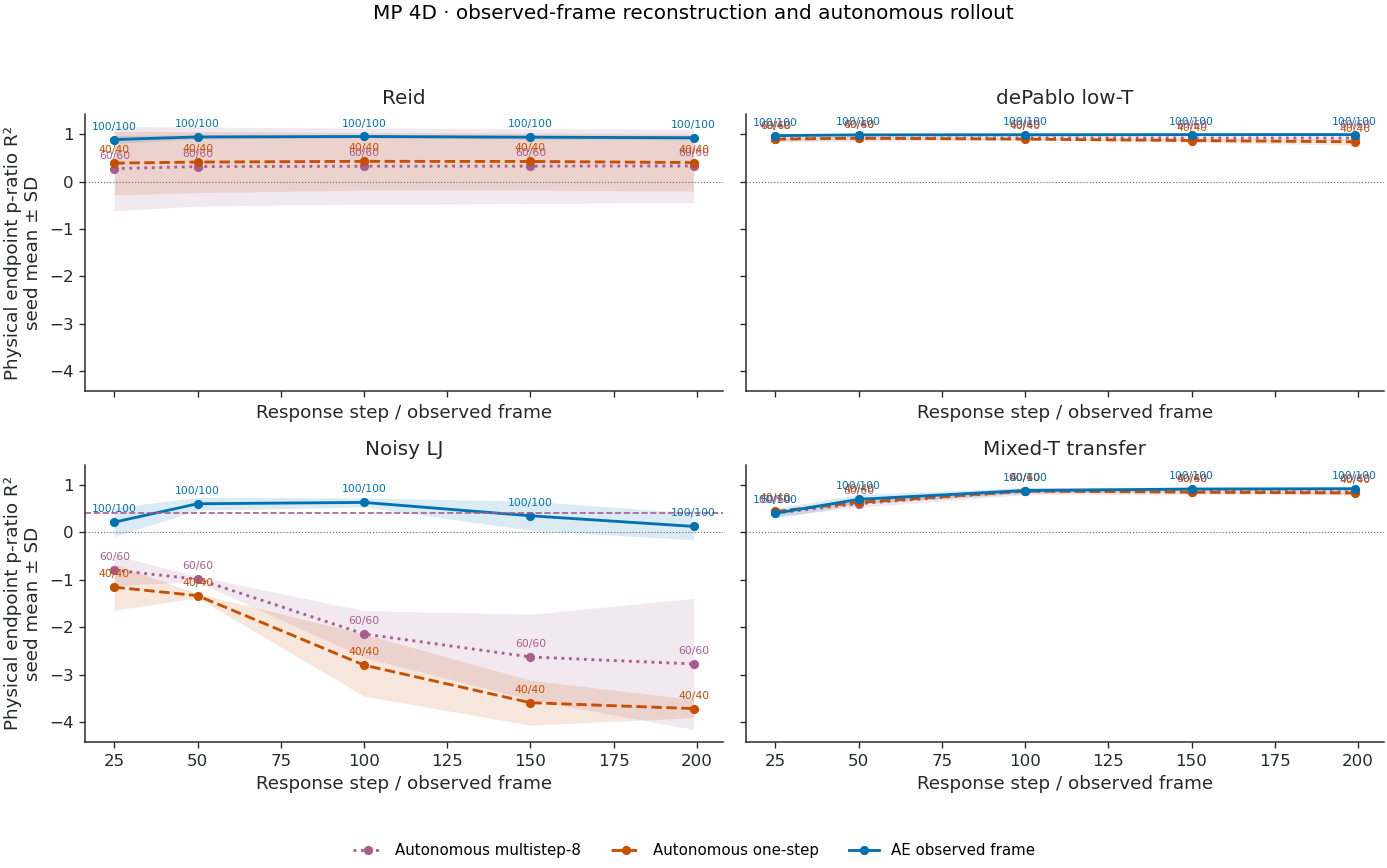

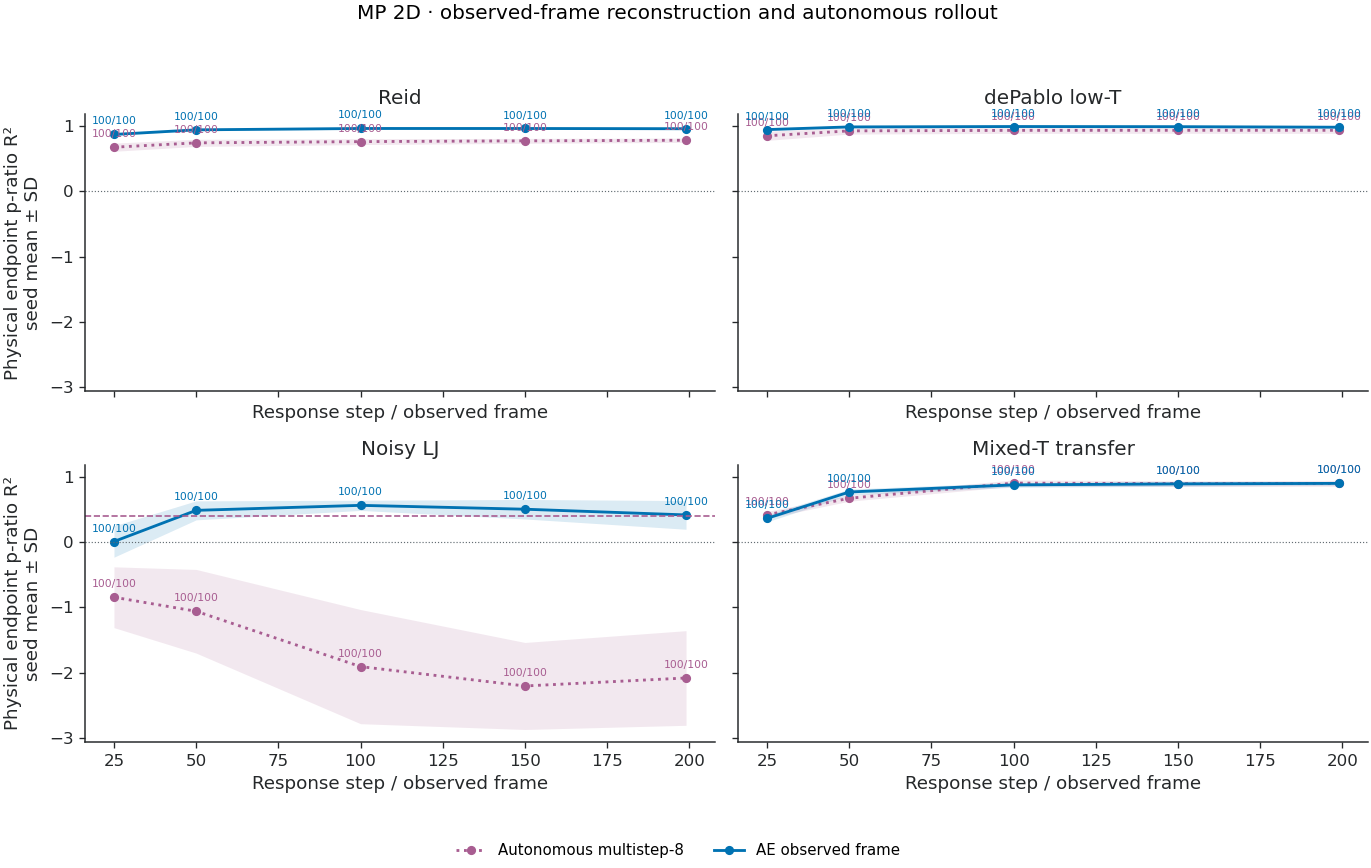

In [4]:
def aggregate_seed_rows(table):
    return (table.groupby(['kind', 'strategy', 'variant_label', 'source', 'frame'], as_index=False)
            .agg(p_ratio_r2_mean=('p_ratio_r2', 'mean'),
                 p_ratio_r2_sd=('p_ratio_r2', 'std'),
                 seeds=('seed', 'nunique'),
                 finite_r2_seeds=('p_ratio_r2', lambda x: x.notna().sum()),
                 valid=('valid', 'sum'),
                 total=('total', 'sum')))

summary = aggregate_seed_rows(response) if not response.empty else pd.DataFrame()
for variant in ('MP 4D', 'MP 2D'):
    panel = summary[summary['variant_label'].eq(variant)] if not summary.empty else summary
    if panel.empty:
        print(f'{variant}: results pending; no curve available yet.')
        continue
    fig, axes = plt.subplots(2, 2, figsize=(11.8, 7.2), sharex=True, sharey=True)
    for ax, source in zip(axes.flat, SOURCES):
        group = panel[panel['source'].eq(source)] if not panel.empty else panel
        if group.empty:
            ax.text(.5, .5, 'No completed rows', transform=ax.transAxes, ha='center', va='center', color=PAPER_COLORS['slate'])
        else:
            for strategy, curve in group.groupby('strategy', sort=False):
                curve = curve.sort_values('frame')
                color = STRATEGY_COLORS.get(strategy, PAPER_COLORS['slate'])
                style = STRATEGY_STYLES.get(strategy, '-')
                ax.plot(curve['frame'], curve['p_ratio_r2_mean'], marker='o', lw=1.7, ms=4.5,
                        ls=style, color=color, label=STRATEGY_LABELS.get(strategy, strategy))
                sd = curve['p_ratio_r2_sd'].fillna(0).to_numpy()
                ax.fill_between(curve['frame'], curve['p_ratio_r2_mean'] - sd, curve['p_ratio_r2_mean'] + sd,
                                color=color, alpha=.14, linewidth=0)
                for row in curve.itertuples():
                    ax.annotate(f'{row.valid}/{row.total}', (row.frame, row.p_ratio_r2_mean),
                                xytext=(0, 6), textcoords='offset points', ha='center', fontsize=6.5, color=color)
        if source == 'lj_noisy':
            ax.axhline(.40, color=DATASET_COLORS['lj_noisy'], lw=1.0, ls='--', label='LJ target 0.40')
        ax.axhline(0, color=PAPER_COLORS['slate'], lw=.7, ls=':')
        ax.set_title(SOURCE_LABELS[source])
        ax.set_xlabel('Response step / observed frame')
    axes[0, 0].set_ylabel('Physical endpoint p-ratio R²\nseed mean ± SD')
    axes[1, 0].set_ylabel('Physical endpoint p-ratio R²\nseed mean ± SD')
    handles, labels = axes[0, 0].get_legend_handles_labels()
    if not handles:
        handles, labels = axes[1, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='lower center', ncol=min(3, len(handles)), frameon=False, bbox_to_anchor=(.5, -.01))
    suffix = '' if not panel.empty else ' · results not available locally'
    fig.suptitle(variant + ' · observed-frame reconstruction and autonomous rollout' + suffix, y=.995, fontsize=12)
    fig.tight_layout(rect=(0, .06, 1, .96))
    plt.show()


In [5]:
if summary.empty:
    print('No completed rows to tabulate.')
else:
    display(summary.sort_values(['variant_label', 'kind', 'strategy', 'source', 'frame']))


,kind,strategy,variant_label,source,frame,p_ratio_r2_mean,p_ratio_r2_sd,seeds,finite_r2_seeds,valid,total
0,autonomous,multistep8,MP 2D,depablo_low_temp,25,0.849194,0.070329,5,5,100,100
1,autonomous,multistep8,MP 2D,depablo_low_temp,50,0.924517,0.049155,5,5,100,100
2,autonomous,multistep8,MP 2D,depablo_low_temp,100,0.932184,0.045736,5,5,100,100
3,autonomous,multistep8,MP 2D,depablo_low_temp,150,0.933245,0.046022,5,5,100,100
4,autonomous,multistep8,MP 2D,depablo_low_temp,199,0.933186,0.047009,5,5,100,100
...,...,...,...,...,...,...,...,...,...,...,...
310,reconstruction,ae,spatial_r16_d8,reid,25,0.808468,0.090445,5,5,100,100
311,reconstruction,ae,spatial_r16_d8,reid,50,0.861461,0.049765,5,5,100,100
312,reconstruction,ae,spatial_r16_d8,reid,100,0.907512,0.026095,5,5,100,100
313,reconstruction,ae,spatial_r16_d8,reid,150,0.930726,0.027243,5,5,100,100


### Noisy LJ: training versus validation
Frozen checkpoints; no additional fitting or reserved-data evaluation.

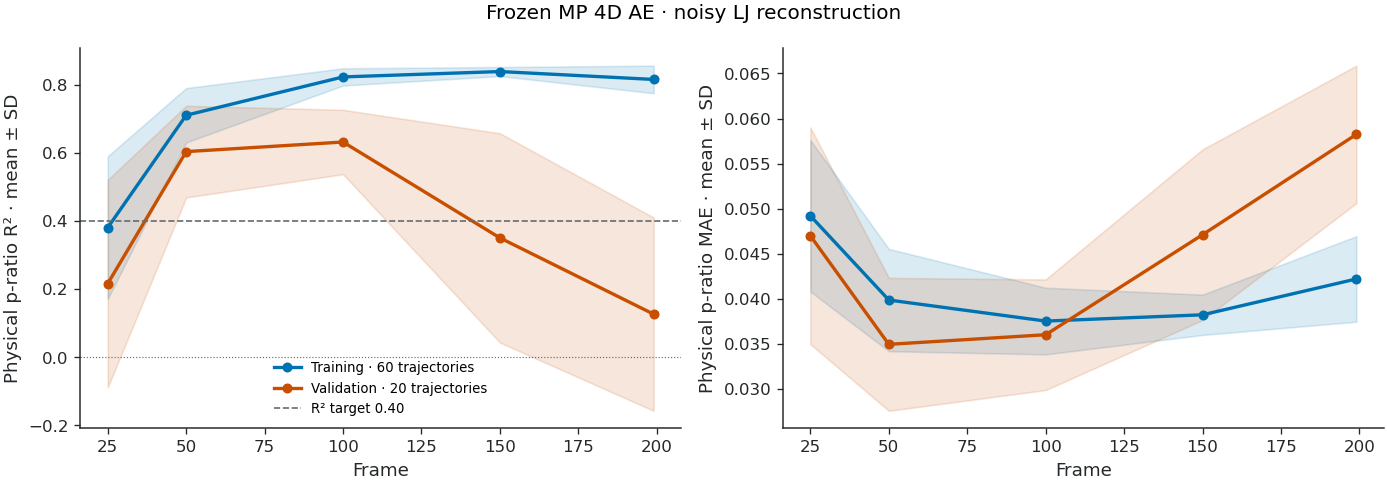

,split,frame,seeds,p_ratio_r2_mean,p_ratio_r2_std,p_ratio_mae_mean,target_variance_mean,valid_sum,total_sum
0,train,25,5,0.381483,0.209600,0.049223,0.006743,300,300
1,train,50,5,0.711751,0.079888,0.039885,0.009735,300,300
2,train,100,5,0.824412,0.025300,0.037551,0.013043,300,300
3,train,150,5,0.840215,0.013289,0.038246,0.014937,300,300
4,train,199,5,0.816993,0.040523,0.042219,0.017069,300,300
5,validation,25,5,0.216834,0.305202,0.047007,0.004217,100,100
6,validation,50,5,0.604857,0.134675,0.034972,0.004872,100,100
7,validation,100,5,0.633038,0.094602,0.036036,0.005393,100,100
8,validation,150,5,0.351259,0.307563,0.047126,0.005919,100,100
9,validation,199,5,0.127035,0.284036,0.058245,0.007100,100,100


The same 60 training and 20 validation trajectories repeat across model seeds. Training scores are in-sample; target variance helps interpret the R² gap.


In [6]:
gap_path = RESULTS / 'compact_lj_training_gap' / 'source_frame_summary.csv'
if not gap_path.exists():
    print('Training-set p-ratio evaluation is still pending.')
else:
    gap = pd.read_csv(gap_path).sort_values(['split', 'frame'])
    fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.2))
    for split, label, color in (
        ('train', 'Training · 60 trajectories', PAPER_COLORS['blue']),
        ('validation', 'Validation · 20 trajectories', PAPER_COLORS['red']),
    ):
        rows = gap[gap['split'].eq(split)]
        for ax, metric in zip(axes, ('p_ratio_r2', 'p_ratio_mae')):
            mean = rows[metric + '_mean'].to_numpy()
            sd = rows[metric + '_std'].to_numpy()
            ax.plot(rows['frame'], mean, marker='o', color=color, label=label)
            ax.fill_between(rows['frame'], mean - sd, mean + sd, color=color, alpha=.14)
            ax.set_xlabel('Frame')
    axes[0].axhline(.4, color=PAPER_COLORS['slate'], ls='--', lw=1, label='R² target 0.40')
    axes[0].axhline(0, color=PAPER_COLORS['slate'], ls=':', lw=.7)
    axes[0].set_ylabel('Physical p-ratio R² · mean ± SD')
    axes[1].set_ylabel('Physical p-ratio MAE · mean ± SD')
    axes[0].legend(frameon=False, fontsize=8)
    fig.suptitle('Frozen MP 4D AE · noisy LJ reconstruction')
    fig.tight_layout()
    plt.show()
    display(gap[['split', 'frame', 'seeds', 'p_ratio_r2_mean', 'p_ratio_r2_std',
                 'p_ratio_mae_mean', 'target_variance_mean', 'valid_sum', 'total_sum']])
    print('The same 60 training and 20 validation trajectories repeat across model seeds. '
          'Training scores are in-sample; target variance helps interpret the R² gap.')
